# Using Shapash with ShapIQ explainer

You can compute local contributions with the [shapiq](https://github.com/mmschlk/shapiq) library and summarize them with Shapash.

Contents:
- Build a Regressor
- Create Explainer using ShapIQ
- Compile Shapash SmartExplainer
- Compare contributions with shap

Data from Kaggle [House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)

In [1]:
# Optional if shapiq is not installed in your environment
# %pip install shapiq

In [ ]:
import warnings
import numpy as np
import pandas as pd
from pandas.api.types import is_string_dtype
from category_encoders import OrdinalEncoder
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
import shapiq

# Silence known shapiq warnings used in this tutorial context.
warnings.filterwarnings(
    "ignore",
    message=r"Mismatch between max_order=2 and index=SV.*",
    category=UserWarning,
    module=r"shapiq\.explainer\.validation"
 )
warnings.filterwarnings(
    "ignore",
    message=r"Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"shapiq\.explainer\.tree\.conversion\.lightgbm"
 )

In [3]:
from shapash.data.data_loader import data_loading
house_df, house_dict = data_loading('house_prices')

In [4]:
y_df = house_df['SalePrice'].to_frame()
X_df = house_df[house_df.columns.difference(['SalePrice'])]

## Create Regression Model

In [5]:
categorical_features = [col for col in X_df.columns if is_string_dtype(X_df[col]) or X_df[col].dtype.name in ('object', 'category')]

encoder = OrdinalEncoder(
    cols=categorical_features,
    handle_unknown='ignore',
    return_df=True
).fit(X_df)

X_df = encoder.transform(X_df)

In [6]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X_df, y_df, train_size=0.75, random_state=1)

In [7]:
regressor = LGBMRegressor(n_estimators=200).fit(Xtrain, ytrain.values.ravel())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2986
[LightGBM] [Info] Number of data points in the train set: 1095, number of used features: 66
[LightGBM] [Info] Start training from score 182319.757078


## Create ShapIQ Explainer

In [8]:
X_background = Xtrain.sample(min(256, len(Xtrain)), random_state=1).values
X_eval = Xtest.reset_index(drop=True)

shapiq_explainer = shapiq.Explainer(
    model=regressor,
    data=X_background,
    index='SV',
    max_order=1
 )

In [9]:
feature_names = list(X_eval.columns)

def first_order_values_to_array(interaction_values, n_features):
    if not hasattr(interaction_values, 'dict_values'):
        raise TypeError(
            "This shapiq version does not expose 'dict_values'; "
            "cannot safely map feature indices to contributions."
        )

    first_order = np.zeros(n_features, dtype=float)
    for coalition, value in interaction_values.dict_values.items():
        # For SV index, first-order effects are stored as singleton coalitions: (feature_index,)
        if isinstance(coalition, tuple) and len(coalition) == 1:
            first_order[int(coalition[0])] = float(value)

    return first_order

In [10]:
shapiq_rows = []
for row in X_eval.values:
    iv = shapiq_explainer.explain(row)
    shapiq_rows.append(first_order_values_to_array(iv, n_features=len(feature_names)))

shapiq_contributions = pd.DataFrame(shapiq_rows, columns=feature_names)

## Use Shapash With ShapIQ Contributions

In [11]:
from shapash import SmartExplainer

In [12]:
xpl = SmartExplainer(
    model=regressor,
    preprocessing=encoder,
    features_dict=house_dict
)

### Use contributions parameter of compile method to declare ShapIQ contributions

In [13]:
xpl.compile(
    contributions=shapiq_contributions.reset_index(drop=True),
    y_target=ytest.reset_index(drop=True),
    x=X_eval
)

In [14]:
app = xpl.run_app(title_story='House Prices Shapiq', port=8020)

INFO:root:Your Shapash application run on http://PMP01087:8020/
INFO:root:Use the method .kill() to down your app.


## Compare contributions to Shap library

### Important note
- `shapiq` and `shap` can satisfy additivity while distributing contributions differently across features.
- A direct one-to-one match by feature is therefore not guaranteed, even when both methods explain the same prediction.

In [15]:
xpl_shap = SmartExplainer(
    model=regressor,
    preprocessing=encoder,
    features_dict=house_dict
)

In [16]:
xpl_shap.compile(
    y_target=ytest.reset_index(drop=True),
    x=X_eval
)

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x11edd1a90>


In [17]:
contributions = {
    'shapiq': xpl.contributions,
    'treeshap': xpl_shap.contributions
}

In [18]:
from shapash.explainer.consistency import Consistency

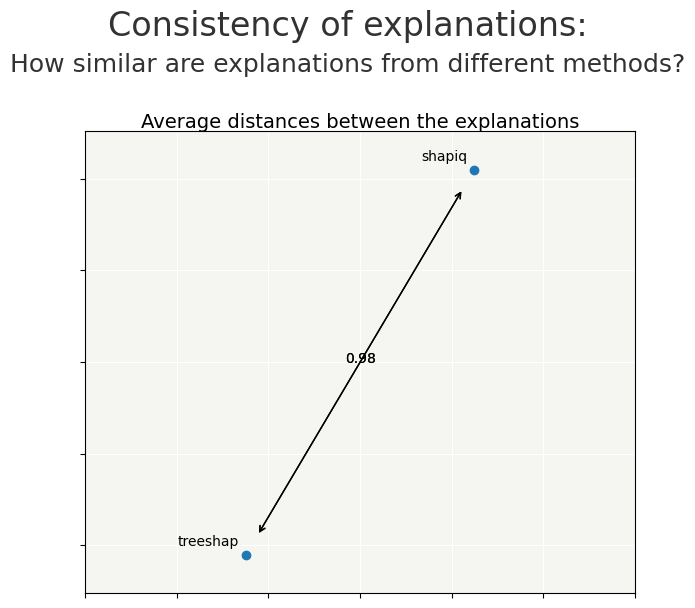

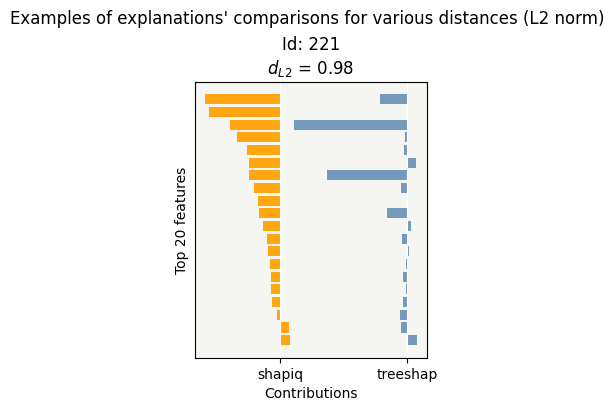

In [19]:
cns = Consistency()
cns.compile(contributions=contributions)
cns.consistency_plot()

## Feature Importances And Feature Correlations
This section compares feature importances derived from ShapIQ and SHAP contributions, and visualizes the feature correlation matrix.

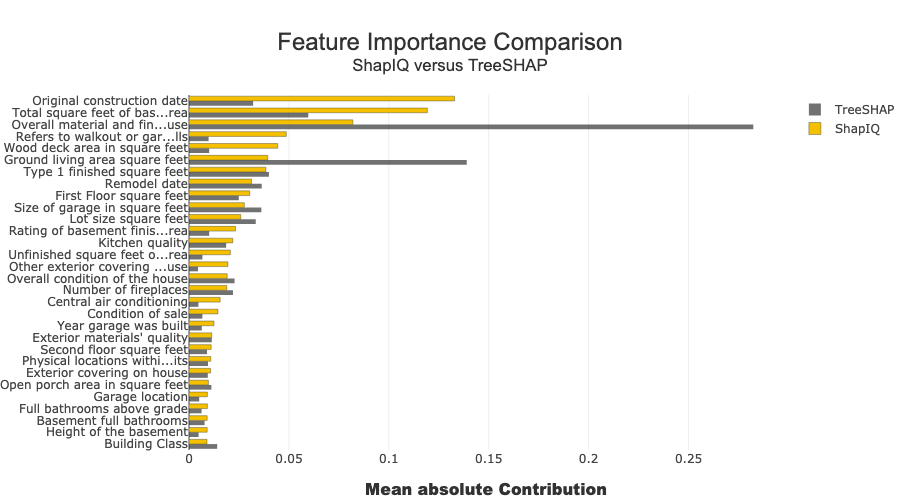

In [20]:
from shapash.plots.plot_feature_importance import plot_feature_importance

xpl.compute_features_import(force=True)
xpl_shap.compute_features_import(force=True)

fi_shapiq = xpl.features_imp.sort_values().tail(30)
fi_shap = xpl_shap.features_imp.reindex(fi_shapiq.index)

fi_shapiq.index = fi_shapiq.index.map(xpl.features_dict)
fi_shap.index = fi_shap.index.map(xpl.features_dict)


fig_fi_compare = plot_feature_importance(
    mode="global",
    global_feat_imp=fi_shapiq.copy(),
    contributions_case=xpl.contributions,
    style_dict=xpl.plot._style_dict,
    subset_feat_imp=fi_shap.copy(),
    title="Feature Importance Comparison",
    addnote="ShapIQ versus TreeSHAP",
    global_feat_imp_name="ShapIQ",
    subset_feat_imp_name="TreeSHAP",
    width=900,
    height=500,
)
fig_fi_compare.show()

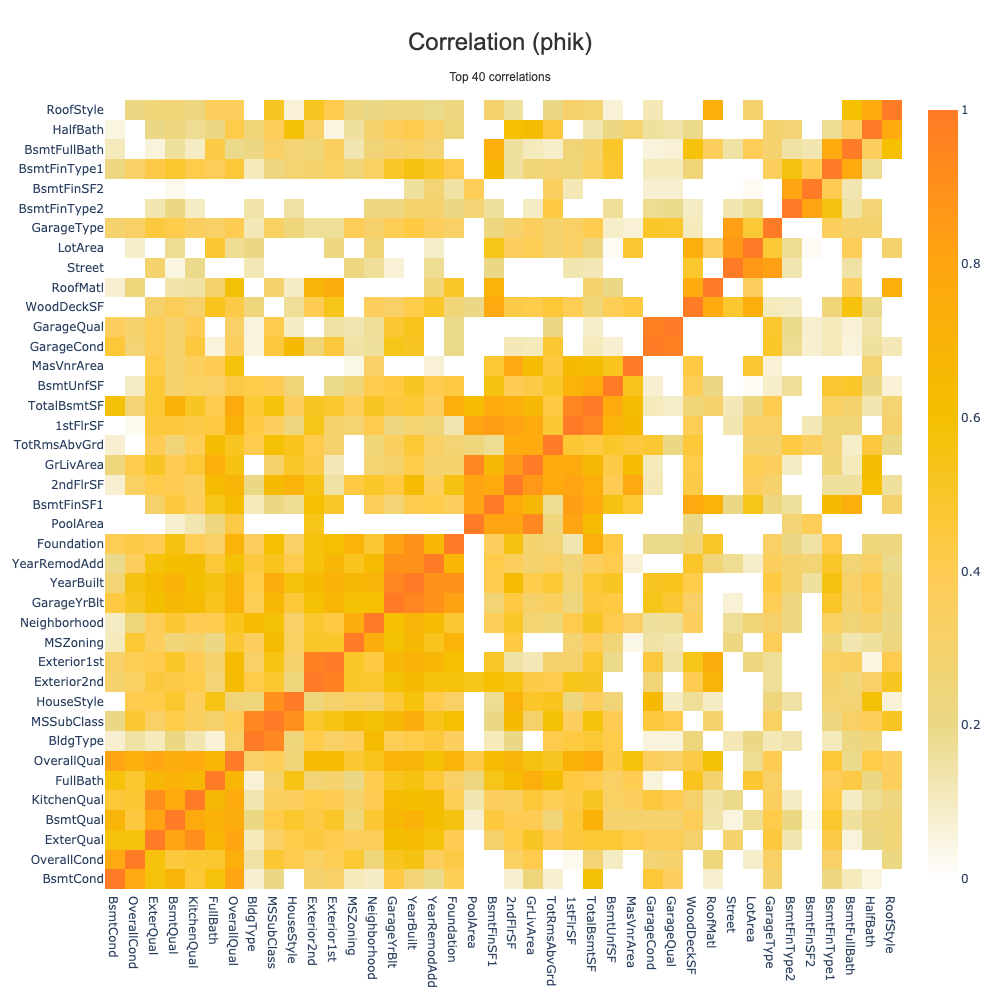

In [21]:
# Correlation matrix with native Shapash plot
fig_corr = xpl.plot.correlations_plot(
    df=X_eval,
    max_features=40,
    height=1000,
    width=1000
 )
fig_corr.show()

## Compare Explainability After Feature Selection
Use a sklearn feature-selection step, then remove highly correlated variables, and compare ShapIQ vs TreeSHAP on the reduced feature space.

In [22]:
from sklearn.feature_selection import SelectFromModel

# 1) Model-based feature selection (LightGBM importances)
selector_model = LGBMRegressor(n_estimators=300, random_state=1)
selector_model.fit(Xtrain, ytrain.values.ravel())

selector = SelectFromModel(selector_model, threshold="median", prefit=True)
selected_mask = selector.get_support()
selected_features = Xtrain.columns[selected_mask].tolist()

print(f"Selected features after model-based filtering: {len(selected_features)} / {Xtrain.shape[1]}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2986
[LightGBM] [Info] Number of data points in the train set: 1095, number of used features: 66
[LightGBM] [Info] Start training from score 182319.757078
Selected features after model-based filtering: 36 / 72


In [23]:
# 2) Correlation-based filtering on selected features
Xtrain_sel = Xtrain[selected_features].copy()
Xtest_sel = Xtest[selected_features].copy()

corr_matrix = Xtrain_sel.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.90
to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
final_features = [f for f in selected_features if f not in to_drop]

Xtrain_red = Xtrain[final_features].reset_index(drop=True)
Xtest_red = Xtest[final_features].reset_index(drop=True)
ytrain_red = ytrain.reset_index(drop=True)
ytest_red = ytest.reset_index(drop=True)

print(f"Features after correlation filtering: {len(final_features)} / {len(selected_features)}")
print(f"Dropped (corr > {corr_threshold}): {len(to_drop)}")

Features after correlation filtering: 36 / 36
Dropped (corr > 0.9): 0


In [24]:
# 3) Train reduced model
regressor_red = LGBMRegressor(n_estimators=200, random_state=1)
regressor_red.fit(Xtrain_red, ytrain_red.values.ravel())

X_background_red = Xtrain_red.sample(min(256, len(Xtrain_red)), random_state=1).values
X_eval_red = Xtest_red.reset_index(drop=True)
feature_names_red = list(X_eval_red.columns)

# 4) Compute ShapIQ contributions on reduced feature set
shapiq_explainer_red = shapiq.Explainer(
    model=regressor_red,
    data=X_background_red,
    index='SV',
    max_order=1
)

shapiq_rows_red = []
for row in X_eval_red.values:
    iv_red = shapiq_explainer_red.explain(row)
    shapiq_rows_red.append(first_order_values_to_array(iv_red, n_features=len(feature_names_red)))

shapiq_contributions_red = pd.DataFrame(shapiq_rows_red, columns=feature_names_red)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2724
[LightGBM] [Info] Number of data points in the train set: 1095, number of used features: 36
[LightGBM] [Info] Start training from score 182319.757078


""
Company Acceptable Use Policy
This is an optional acceptable use disclaimer that appears on every page. You may change the wording or remove this section entirely in index.html.
"For assistance, please contact your system administrator."
generated 2026-06-04 18:10:45 by Skyhigh Secure Web Gateway python-requests/2.34.2


INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x129bf7920>


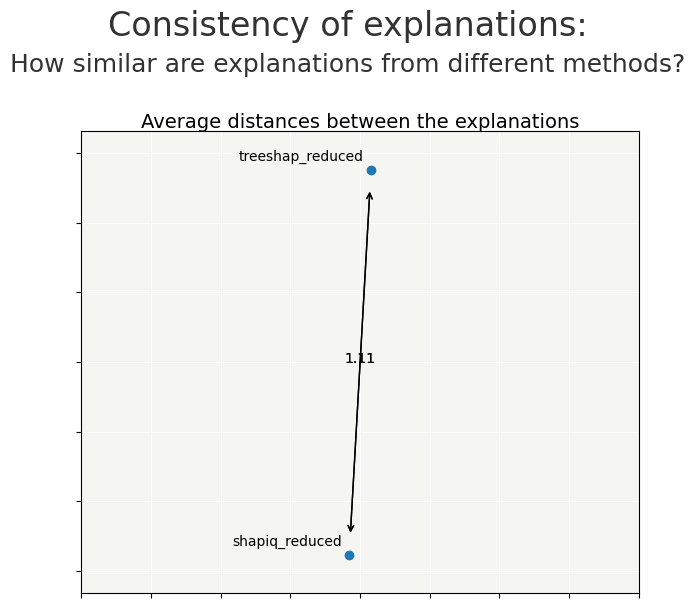

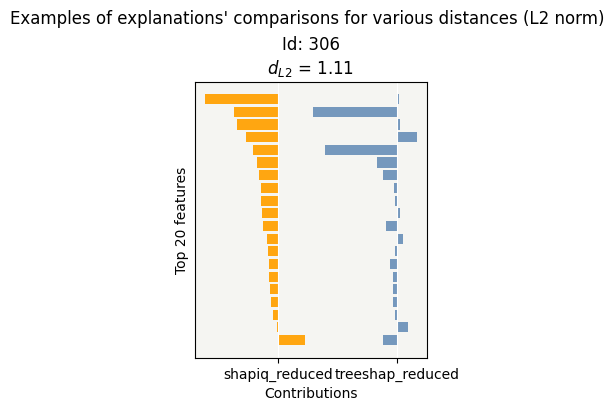

In [25]:
# 5) Compile two Shapash explainers on reduced feature space
xpl_shapiq_red = SmartExplainer(
    model=regressor_red,
    preprocessing=None,
    features_dict=house_dict
)
xpl_shapiq_red.compile(
    contributions=shapiq_contributions_red.reset_index(drop=True),
    y_target=ytest_red.reset_index(drop=True),
    x=X_eval_red
)

xpl_shap_red = SmartExplainer(
    model=regressor_red,
    preprocessing=None,
    features_dict=house_dict
)
xpl_shap_red.compile(
    y_target=ytest_red.reset_index(drop=True),
    x=X_eval_red
)

# 6) Compare consistency after feature selection
contributions_red = {
    'shapiq_reduced': xpl_shapiq_red.contributions,
    'treeshap_reduced': xpl_shap_red.contributions
}

cns_red = Consistency()
cns_red.compile(contributions=contributions_red)
cns_red.consistency_plot()

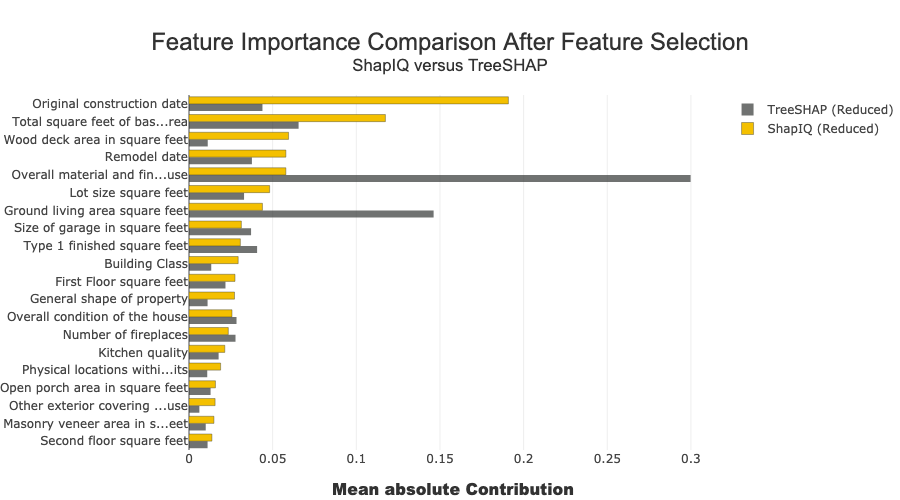

In [26]:
from shapash.plots.plot_feature_importance import plot_feature_importance

xpl_shapiq_red.compute_features_import(force=True)
xpl_shap_red.compute_features_import(force=True)

fi_shapiq_red = xpl_shapiq_red.features_imp.sort_values().tail(20)
fi_shap_red = xpl_shap_red.features_imp.reindex(fi_shapiq_red.index)

fig_fi_compare_red = plot_feature_importance(
    mode="global",
    global_feat_imp=fi_shapiq_red.copy(),
    contributions_case=xpl_shapiq_red.contributions,
    style_dict=xpl_shapiq_red.plot._style_dict,
    features_dict=xpl_shapiq_red.features_dict,
    subset_feat_imp=fi_shap_red.copy(),
    title="Feature Importance Comparison After Feature Selection",
    addnote="ShapIQ versus TreeSHAP",
    global_feat_imp_name="ShapIQ (Reduced)",
    subset_feat_imp_name="TreeSHAP (Reduced)",
    width=900,
    height=500,
)
fig_fi_compare_red.show()